# 23CO315 - Piyusha Supe

**NLP - Practical 2**



Perform bag-of-words approach (count occurrence, normalized count occurrence), TF-IDF on
data.  Create embeddings using Word2Vec.
Dataset to be used: https://www.kaggle.com/datasets/CooperUnion/cardataset

In [2]:
# If running first time (uncomment if needed)
!pip install pandas numpy nltk scikit-learn gensim matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download required resources
nltk.download('punkt')
nltk.download('stopwords')

# Set style (no explicit colors used)
plt.style.use('default')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.0 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:

from google.colab import files

uploaded = files.upload()


Saving NLP__Practical_2_data.csv to NLP__Practical_2_data.csv


In [7]:
# Load dataset (update path if needed)
df = pd.read_csv('/content/NLP__Practical_2_data.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
# Select relevant text columns
text_columns = [
    'Make',
    'Model',
    'Engine Fuel Type',
    'Vehicle Style'
]

# Fill missing values
df[text_columns] = df[text_columns].fillna('')

# Combine text columns
df['combined_text'] = df[text_columns].agg(' '.join, axis=1)

# Convert to lowercase
df['combined_text'] = df['combined_text'].str.lower()

print("Sample Combined Text:\n")
print(df['combined_text'].head())

Sample Combined Text:

0     bmw 1 series m premium unleaded (required) coupe
1    bmw 1 series premium unleaded (required) conve...
2       bmw 1 series premium unleaded (required) coupe
3       bmw 1 series premium unleaded (required) coupe
4    bmw 1 series premium unleaded (required) conve...
Name: combined_text, dtype: object


In [10]:
nltk.download('punkt_tab')
# Tokenize sentences
tokenized_sentences = [word_tokenize(text) for text in df['combined_text']]

# Flatten tokens
all_words = [word for sentence in tokenized_sentences for word in sentence]

print("Sample Tokens:\n", tokenized_sentences[:2])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Sample Tokens:
 [['bmw', '1', 'series', 'm', 'premium', 'unleaded', '(', 'required', ')', 'coupe'], ['bmw', '1', 'series', 'premium', 'unleaded', '(', 'required', ')', 'convertible']]


In [11]:
count_vectorizer = CountVectorizer(stop_words='english')

bow_matrix = count_vectorizer.fit_transform(df['combined_text'])

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

print("BoW Shape:", bow_df.shape)
bow_df.head()

BoW Shape: (11914, 815)


,10,100,124,12c,15,150,1500,1500hd,16,190,...,xv,yaris,yorker,yukon,z3,z4,z71,z8,zdx,zephyr
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
normalized_bow = bow_df.div(bow_df.sum(axis=1), axis=0)

print("Normalized BoW Sample:")
normalized_bow.head()

Normalized BoW Sample:


,10,100,124,12c,15,150,1500,1500hd,16,190,...,xv,yaris,yorker,yukon,z3,z4,z71,z8,zdx,zephyr
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("TF-IDF Shape:", tfidf_df.shape)
tfidf_df.head()

TF-IDF Shape: (11914, 815)


,10,100,124,12c,15,150,1500,1500hd,16,190,...,xv,yaris,yorker,yukon,z3,z4,z71,z8,zdx,zephyr
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Vocabulary Size:", len(w2v_model.wv))

# Example vector
sample_word = list(w2v_model.wv.index_to_key)[0]
print(f"\nSample Word: {sample_word}")
print(w2v_model.wv[sample_word])

Vocabulary Size: 851

Sample Word: unleaded
[-2.59048015e-01  2.27174863e-01  9.42094624e-02  1.10470697e-01
 -3.33828293e-02  1.03917405e-01  2.31598973e-01  2.25575328e-01
 -3.35768908e-01  1.25567764e-01  8.23296383e-02  4.16509807e-02
  1.97366670e-01 -2.87103523e-02  3.21340337e-02 -1.83589756e-01
 -8.08680952e-02  2.32814983e-01 -5.18768549e-01 -2.13810921e-01
 -3.85139510e-02 -5.99010997e-02  7.93087929e-02  3.86963189e-02
  1.51853591e-01 -2.75971415e-03  5.77180028e-01  3.15781720e-02
 -3.50146741e-01 -2.07018942e-01 -1.93103865e-01 -1.47924200e-01
  1.95923150e-01  1.02565043e-01 -3.01696062e-01  1.41839355e-01
  2.29965568e-01 -1.19255133e-01  9.24933851e-02 -2.16314316e-01
 -1.41747281e-01  1.59167975e-01 -2.48750508e-01 -2.01337427e-01
 -1.10641196e-02 -2.23436020e-02  8.82572159e-02  1.02927633e-01
  1.38270453e-01  3.05061162e-01 -1.72974050e-01 -2.70540193e-02
 -3.90483379e-01 -5.09580888e-04 -1.62419118e-02 -1.67784721e-01
  1.67534813e-01 -2.29858220e-01 -1.23589247e-

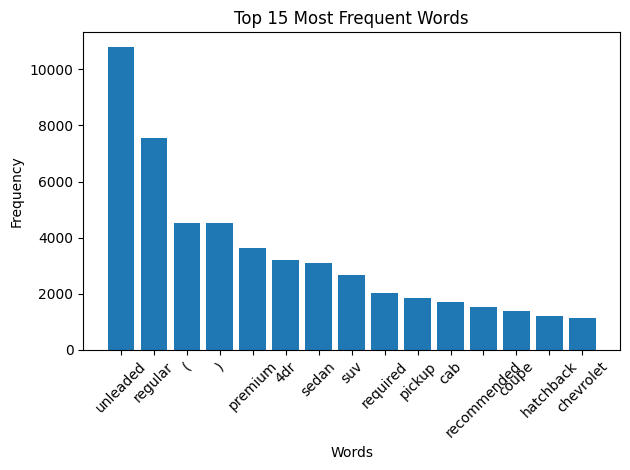

In [15]:
word_freq = Counter(all_words)

top_words = word_freq.most_common(15)
words, counts = zip(*top_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

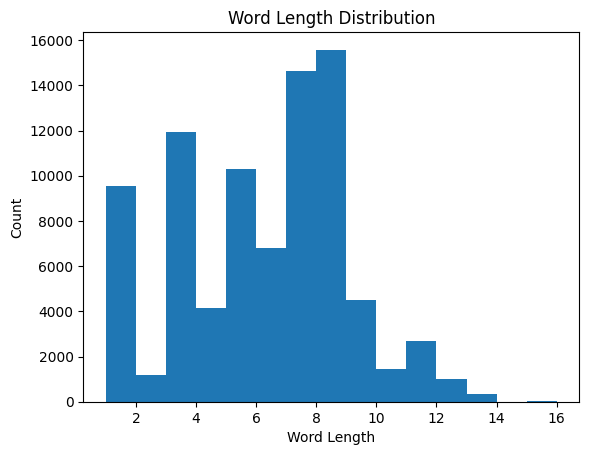

In [17]:
word_lengths = [len(word) for word in all_words]

plt.figure()
plt.hist(word_lengths, bins=15)
plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.show()

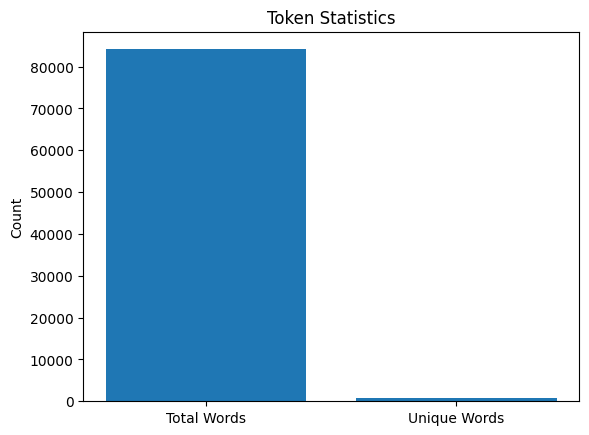

In [18]:
methods = ['Total Words', 'Unique Words']
values = [len(all_words), len(set(all_words))]

plt.figure()
plt.bar(methods, values)
plt.title("Token Statistics")
plt.ylabel("Count")
plt.show()

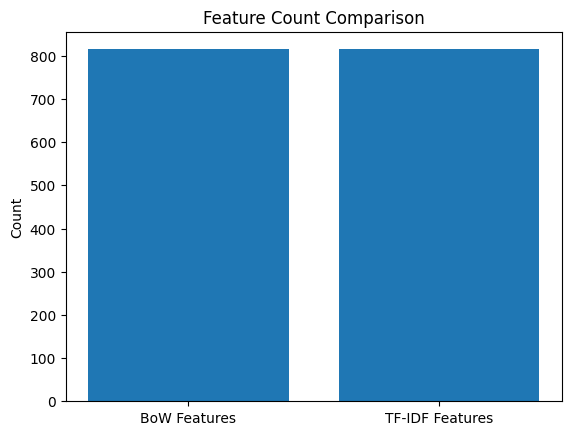

In [19]:
labels = ['BoW Features', 'TF-IDF Features']
values = [bow_df.shape[1], tfidf_df.shape[1]]

plt.figure()
plt.bar(labels, values)
plt.title("Feature Count Comparison")
plt.ylabel("Count")
plt.show()

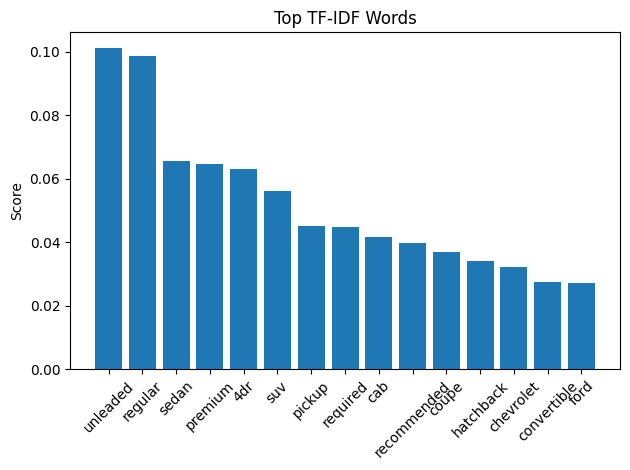

In [20]:
# Get average TF-IDF scores
tfidf_means = tfidf_df.mean(axis=0)

top_tfidf = tfidf_means.sort_values(ascending=False).head(15)

plt.figure()
plt.bar(top_tfidf.index, top_tfidf.values)
plt.xticks(rotation=45)
plt.title("Top TF-IDF Words")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

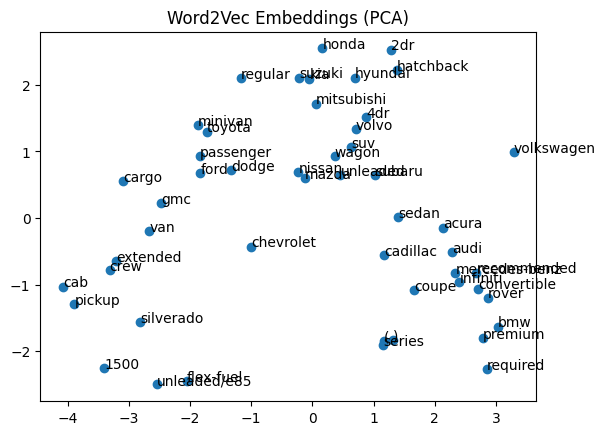

In [21]:
from sklearn.decomposition import PCA

# Take top words
words = list(w2v_model.wv.index_to_key)[:50]
vectors = [w2v_model.wv[word] for word in words]

# Reduce to 2D
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure()
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word2Vec Embeddings (PCA)")
plt.show()

Piyusha Supe
